# Exercise 4

## Import packages

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

## Task 1
(3 points)

Implement the training loop for one training epoch.
An epoch trains on the whole training dataset once.

In [26]:
def train(model, use_cuda, train_loader, optimizer, epoch, log_interval):
    """
    Train one epoch
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    train_loader -- data loader
    optimizer -- network optimizer
    epoch -- number of current epoch
    log_interval -- number of training steps between logs
    """
    # TODO: set the model to train mode
    model.train()

    # TODO: enumerate over the dataloader to get mini batches
    #       of images and ground truth labels
    # HINT: the builtin python function enumerate() also gives you indices
    for batch_idx, (data, target) in enumerate(train_loader):
        # TODO: set the optimizers gradients to zero
        optimizer.zero_grad()
        
        # TODO: run the network
        if use_cuda:
            data, target = data.cuda(), target.cuda()
        output = model(data)
        
        # TODO: compute negative log likelihood loss
        loss = F.nll_loss(output, target)
        
        # TODO: do backpropagation
        loss.backward()
        
        # TODO: optimize
        optimizer.step()
        
        # TODO: print current loss for every nth ("log_interval"th) iteration
        if (batch_idx + 1) % log_interval == 0:
            print(
                "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                    epoch,
                    batch_idx * data.size(0),
                    len(train_loader.dataset) if hasattr(train_loader, "dataset") else "?",
                    100. * batch_idx / len(train_loader) if hasattr(train_loader, "__len__") else 0.0,
                    loss.item(),
                ),
                flush=True,
            )
        

We already implemented the validation function for you (this is essentially validate() from the last exercise)

In [13]:
def validate(model, use_cuda, test_loader):
    """
    Compute test metrics
    
    model -- the neural network
    use_cuda -- true if GPU should be used
    test_loader -- data loader
    """
    # create a 10x10 grid of subplots
    _, axis = plt.subplots(10, 10)
    
    # set model to evaluation mode
    model.eval()
    test_loss = 0
    correct = 0
    plotted = 0
    
    # disable gradients globally
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            # for each batch
            if use_cuda:
                # transfer to GPU
                data = data.cuda()
                target = target.cuda()
            
            # run network and compute metrics
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            
            img_correct = pred.eq(target.view_as(pred))
            correct += pred.eq(target.view_as(pred)).sum().item()
            
            # plot the first 100 images
            img_idx = 0
            data = data.cpu().numpy()
            
            while plotted < 100 and img_idx < data.shape[0]:
                # compute position of ith image in the grid
                y = plotted % 10
                x = plotted // 10
                
                # convert image tensor to numpy array and normalize to [0, 1]
                img = data[img_idx, 0]
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
                
                # make wrongly predicted images red
                img = np.stack([img] * 3, 2)
                if img_correct[img_idx] == 0:
                    img[:, :, 1:] = 0.0
                
                # disable axis and show image
                axis[y][x].axis('off')
                axis[y][x].imshow(img)
                
                # show the predicted class next to each image
                axis[y][x].text(30, 25, pred[img_idx].item())
                
                plotted += 1
                img_idx += 1
            
    test_loss /= len(test_loader.dataset)

    # show results
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    plt.show()

## Task 2
(4 points)

Implement a five-layer fully connected neural network.
The dimensions (without batch size) should change like this: 784->200->100->60->30->10
Use log softmax to compute the class predictions.

Run the code at the end of the notebook to train and validate your implementation.

### Task 2.1
* sigmoid non-linear activation function
* note that the last layer does not need an activation function!

### Task 2.2
* add a new class "FCNet2"
* replace sigmoid with ReLU

### Task 2.3
* add a new class "FCNet2"
* add batch normalization to the first and third layers (note the difference between 1D/2D/3D versions)


**NOTE:** The perfomance should improve slightly with each step. However, due to the random weight initialization applied by PyTorch, your results may vary a bit between trainings.

In [14]:
class FCNet1(nn.Module):
    """
    Fully Connected Neural Network
    
    Five fully connected layers with sigmoid non-linearity
    
    Dimensions
    784->200->100->60->30->10
    """
    def __init__(self):
        super(FCNet1, self).__init__()
        
        # TODO: initialize network layers
        # HINT: take a look at "torch.nn" (imported as "nn")
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

    def forward(self, x):
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(-1, 784)
        
        # TODO: run network layers
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        x = self.fc5(x)
        
        # TODO: compute log softmax over the output
        # HINT: take a look at "torch.nn.functional" (imported as "F")
        return F.log_softmax(x, dim=1)

In [25]:
class FCNet2(nn.Module):
    def __init__(self):
        super(FCNet2, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return F.log_softmax(x, dim=1)

In [36]:
class FCNet3(nn.Module):
    def __init__(self):
        super(FCNet3, self).__init__()
        self.fc1 = nn.Linear(784, 200)
        self.bn1 = nn.BatchNorm1d(200)    # batch norm after fc1 (layer 1)
        self.fc2 = nn.Linear(200, 100)
        self.fc3 = nn.Linear(100, 60)
        self.bn3 = nn.BatchNorm1d(60)     # batch norm after fc3 (layer 3)
        self.fc4 = nn.Linear(60, 30)
        self.fc5 = nn.Linear(30, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.bn3(self.fc3(x)))
        x = torch.relu(self.fc4(x))
        x = self.fc5(x)
        return F.log_softmax(x, dim=1)

## Task 3
(3 points)

Implement a convolutional neural network, consisting of two convolutional and two fully connected layers.
This time, the dimensions (without batch size) should change like this: 1x28x28->32x26x26->64x12x12->128->10

### Task 3.1
* two convolutional layers (kernel size 3)
* two fully-connected layers
* ReLU activation function

### Task 3.2
* add batch normalization to first convolutional and first fully connected layer

### Task 3.3
* use max pooling instead of stride to reduce the dimensions to 64x12x12

In [29]:
class ConvNet1(nn.Module):
    """
    Convolutional Neural Network
    
    Two convolutional layers and two fully connected layers
    
    Dimensions:
    1x28x28->32x26x26->64x12x12->128->10
    """
    def __init__(self):
        super(ConvNet1, self).__init__()
        
        # TODO: initialize network layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)    # 1x28x28 -> 32x26x26
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)    # 32x26x26 -> 64x12x12
        self.fc1 = nn.Linear(64 * 12 * 12, 128)    # 64x12x12 -> 128
        self.fc2 = nn.Linear(128, 10)    # 128 -> 10
        

    def forward(self, x):
        # TODO: run convolutional layers
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        # TODO: reshape batch of images to batch of 1D vectors
        x = x.view(x.size(0), -1)
        
        # TODO: run fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        # TODO: compute log softmax over the output
        return F.log_softmax(x, dim=1)

In [33]:
class ConvNet2(nn.Module):
    def __init__(self):
        super(ConvNet2, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)    # 1x28x28 -> 32x26x26
        self.bn_conv = nn.BatchNorm2d(32)               # batch norm for first conv
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2)    # 32x26x26 -> 64x12x12
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.bn_fc = nn.BatchNorm1d(128)                # batch norm for first FC
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn_conv(x)
        x = F.relu(x)
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [34]:
class ConvNet3(nn.Module):
    def __init__(self):
        super(ConvNet3, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)    # 1x28x28 -> 32x26x26
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)   # 32x26x26 -> 64x24x24
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)    # 64x24x24 -> 64x12x12
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

Train Epoch: 1 [6336/60000 (11%)]	Loss: 0.223688
Train Epoch: 1 [12736/60000 (21%)]	Loss: 0.234221
Train Epoch: 1 [19136/60000 (32%)]	Loss: 0.444245
Train Epoch: 1 [25536/60000 (43%)]	Loss: 0.087658
Train Epoch: 1 [31936/60000 (53%)]	Loss: 0.261957
Train Epoch: 1 [38336/60000 (64%)]	Loss: 0.134122
Train Epoch: 1 [44736/60000 (75%)]	Loss: 0.100790
Train Epoch: 1 [51136/60000 (85%)]	Loss: 0.132663
Train Epoch: 1 [57536/60000 (96%)]	Loss: 0.075944

Test set: Average loss: 0.1417, Accuracy: 9568/10000 (95.68%)



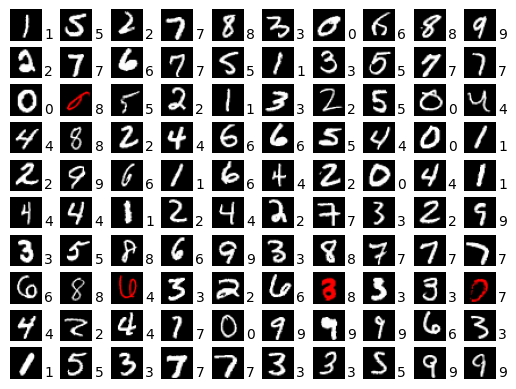

Train Epoch: 2 [6336/60000 (11%)]	Loss: 0.035061
Train Epoch: 2 [12736/60000 (21%)]	Loss: 0.060937
Train Epoch: 2 [19136/60000 (32%)]	Loss: 0.057662
Train Epoch: 2 [25536/60000 (43%)]	Loss: 0.058482
Train Epoch: 2 [31936/60000 (53%)]	Loss: 0.085053
Train Epoch: 2 [38336/60000 (64%)]	Loss: 0.142613
Train Epoch: 2 [44736/60000 (75%)]	Loss: 0.079530
Train Epoch: 2 [51136/60000 (85%)]	Loss: 0.085703
Train Epoch: 2 [57536/60000 (96%)]	Loss: 0.099325

Test set: Average loss: 0.0917, Accuracy: 9734/10000 (97.34%)



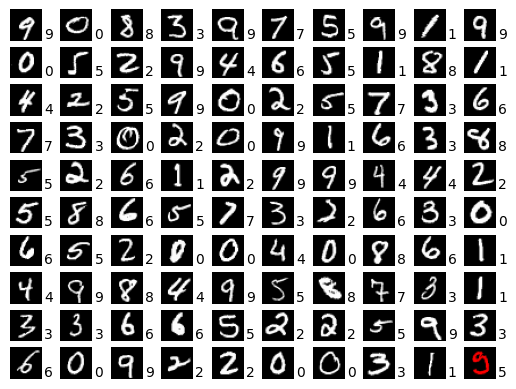

Train Epoch: 3 [6336/60000 (11%)]	Loss: 0.157766
Train Epoch: 3 [12736/60000 (21%)]	Loss: 0.077734
Train Epoch: 3 [19136/60000 (32%)]	Loss: 0.023544
Train Epoch: 3 [25536/60000 (43%)]	Loss: 0.048002
Train Epoch: 3 [31936/60000 (53%)]	Loss: 0.232438
Train Epoch: 3 [38336/60000 (64%)]	Loss: 0.034507
Train Epoch: 3 [44736/60000 (75%)]	Loss: 0.031190
Train Epoch: 3 [51136/60000 (85%)]	Loss: 0.019718
Train Epoch: 3 [57536/60000 (96%)]	Loss: 0.003571

Test set: Average loss: 0.0862, Accuracy: 9756/10000 (97.56%)



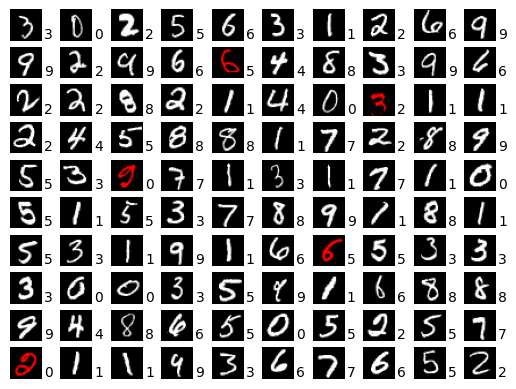

Train Epoch: 4 [6336/60000 (11%)]	Loss: 0.006464
Train Epoch: 4 [12736/60000 (21%)]	Loss: 0.006144
Train Epoch: 4 [19136/60000 (32%)]	Loss: 0.001990
Train Epoch: 4 [25536/60000 (43%)]	Loss: 0.008284
Train Epoch: 4 [31936/60000 (53%)]	Loss: 0.027801
Train Epoch: 4 [38336/60000 (64%)]	Loss: 0.004102
Train Epoch: 4 [44736/60000 (75%)]	Loss: 0.000446
Train Epoch: 4 [51136/60000 (85%)]	Loss: 0.007100
Train Epoch: 4 [57536/60000 (96%)]	Loss: 0.000339

Test set: Average loss: 0.0865, Accuracy: 9775/10000 (97.75%)



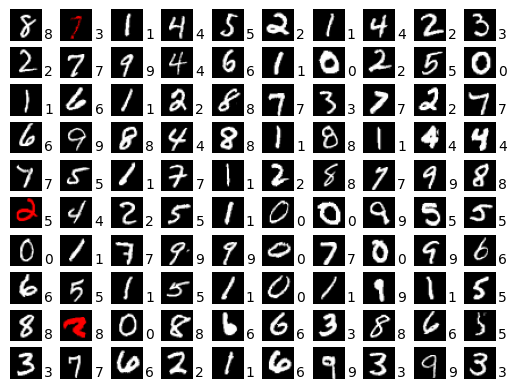

Train Epoch: 5 [6336/60000 (11%)]	Loss: 0.032348
Train Epoch: 5 [12736/60000 (21%)]	Loss: 0.003028
Train Epoch: 5 [19136/60000 (32%)]	Loss: 0.072363
Train Epoch: 5 [25536/60000 (43%)]	Loss: 0.106407
Train Epoch: 5 [31936/60000 (53%)]	Loss: 0.009196
Train Epoch: 5 [38336/60000 (64%)]	Loss: 0.020789
Train Epoch: 5 [44736/60000 (75%)]	Loss: 0.001510
Train Epoch: 5 [51136/60000 (85%)]	Loss: 0.129909
Train Epoch: 5 [57536/60000 (96%)]	Loss: 0.001524

Test set: Average loss: 0.0800, Accuracy: 9803/10000 (98.03%)



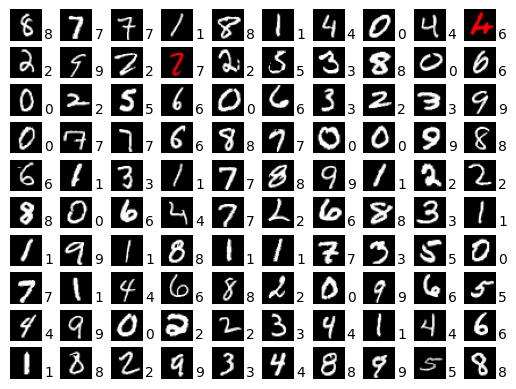

Train Epoch: 6 [6336/60000 (11%)]	Loss: 0.005768
Train Epoch: 6 [12736/60000 (21%)]	Loss: 0.013728
Train Epoch: 6 [19136/60000 (32%)]	Loss: 0.017520
Train Epoch: 6 [25536/60000 (43%)]	Loss: 0.000238
Train Epoch: 6 [31936/60000 (53%)]	Loss: 0.008333
Train Epoch: 6 [38336/60000 (64%)]	Loss: 0.029693
Train Epoch: 6 [44736/60000 (75%)]	Loss: 0.002648
Train Epoch: 6 [51136/60000 (85%)]	Loss: 0.017504
Train Epoch: 6 [57536/60000 (96%)]	Loss: 0.003070

Test set: Average loss: 0.0840, Accuracy: 9811/10000 (98.11%)



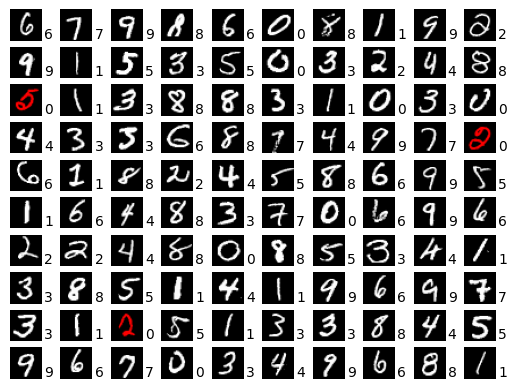

Train Epoch: 7 [6336/60000 (11%)]	Loss: 0.000429
Train Epoch: 7 [12736/60000 (21%)]	Loss: 0.011055
Train Epoch: 7 [19136/60000 (32%)]	Loss: 0.000300
Train Epoch: 7 [25536/60000 (43%)]	Loss: 0.001592
Train Epoch: 7 [31936/60000 (53%)]	Loss: 0.001080
Train Epoch: 7 [38336/60000 (64%)]	Loss: 0.004987
Train Epoch: 7 [44736/60000 (75%)]	Loss: 0.001602
Train Epoch: 7 [51136/60000 (85%)]	Loss: 0.010165
Train Epoch: 7 [57536/60000 (96%)]	Loss: 0.001210

Test set: Average loss: 0.0858, Accuracy: 9810/10000 (98.10%)



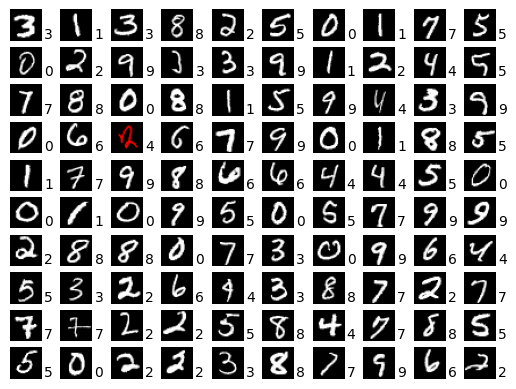

Train Epoch: 8 [6336/60000 (11%)]	Loss: 0.001194
Train Epoch: 8 [12736/60000 (21%)]	Loss: 0.000845
Train Epoch: 8 [19136/60000 (32%)]	Loss: 0.002223
Train Epoch: 8 [25536/60000 (43%)]	Loss: 0.000993
Train Epoch: 8 [31936/60000 (53%)]	Loss: 0.000275
Train Epoch: 8 [38336/60000 (64%)]	Loss: 0.000569
Train Epoch: 8 [44736/60000 (75%)]	Loss: 0.012407
Train Epoch: 8 [51136/60000 (85%)]	Loss: 0.000402
Train Epoch: 8 [57536/60000 (96%)]	Loss: 0.002118

Test set: Average loss: 0.0889, Accuracy: 9801/10000 (98.01%)



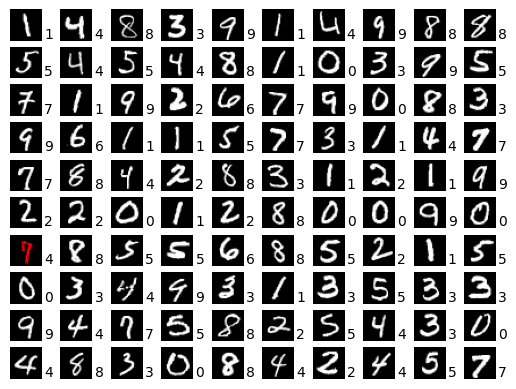

Train Epoch: 9 [6336/60000 (11%)]	Loss: 0.000800
Train Epoch: 9 [12736/60000 (21%)]	Loss: 0.000171
Train Epoch: 9 [19136/60000 (32%)]	Loss: 0.000229
Train Epoch: 9 [25536/60000 (43%)]	Loss: 0.001814
Train Epoch: 9 [31936/60000 (53%)]	Loss: 0.003154
Train Epoch: 9 [38336/60000 (64%)]	Loss: 0.000758
Train Epoch: 9 [44736/60000 (75%)]	Loss: 0.000324
Train Epoch: 9 [51136/60000 (85%)]	Loss: 0.002558
Train Epoch: 9 [57536/60000 (96%)]	Loss: 0.000160

Test set: Average loss: 0.0925, Accuracy: 9801/10000 (98.01%)



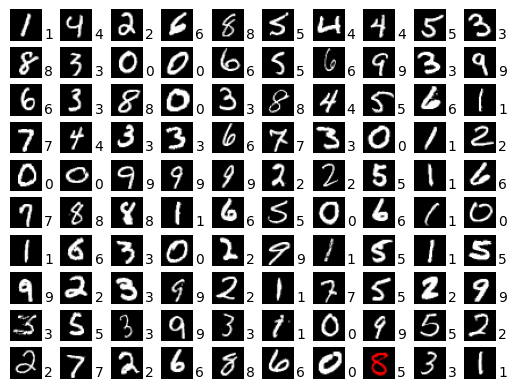

Train Epoch: 10 [6336/60000 (11%)]	Loss: 0.000304
Train Epoch: 10 [12736/60000 (21%)]	Loss: 0.000777
Train Epoch: 10 [19136/60000 (32%)]	Loss: 0.000146
Train Epoch: 10 [25536/60000 (43%)]	Loss: 0.002380
Train Epoch: 10 [31936/60000 (53%)]	Loss: 0.005337
Train Epoch: 10 [38336/60000 (64%)]	Loss: 0.001913
Train Epoch: 10 [44736/60000 (75%)]	Loss: 0.000814
Train Epoch: 10 [51136/60000 (85%)]	Loss: 0.002280
Train Epoch: 10 [57536/60000 (96%)]	Loss: 0.000496

Test set: Average loss: 0.0931, Accuracy: 9798/10000 (97.98%)



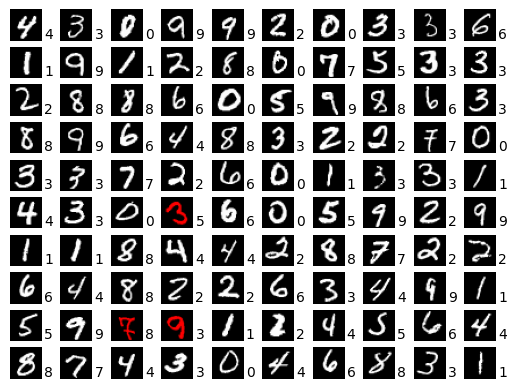

In [37]:
# hyper parameters
batch_size = 64
test_batch_size = 1000
epochs = 10
lr = 1.0
gamma = 0.7
log_interval = 100

# use GPU if available
use_cuda = torch.cuda.is_available()
kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

# initialize data loaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])), batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, 
    transform=transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.1307,), (0.3081,))
    ])),
    batch_size=test_batch_size, shuffle=True, **kwargs)

model = FCNet2()
if use_cuda:
    model = model.cuda()

# initialize optimizer and scheduler
optimizer = optim.Adadelta(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

for epoch in range(1, epochs + 1):
    # train one epoch
    train(model, use_cuda, train_loader, optimizer, epoch, log_interval)
    
    # run on test dataset
    validate(model, use_cuda, test_loader)
    scheduler.step()
    
    
    torch.save(model.state_dict(), "models/mnist/checkpoint.pt")